# Exercise 1 — Tabular Classification
### Rice Type Classifier

---

## The Problem

A rice processing company receives mixed batches of two rice varieties —
**Cammeo** and **Osmancik** — and needs to sort them automatically
using physical measurements taken by a camera system.

You are the ML engineer. Given a dataset of grain measurements,
build a classifier that identifies the rice type.

---

## The Data

```python
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/mssmartypants/rice-type-classification")
```

A CSV file with physical measurements of individual rice grains:
area, perimeter, axis lengths, eccentricity, convex area, and more.
The target column is `Class`.

⚠️ **One thing worth knowing:** the raw feature values are on very different
scales. A model trained on un-normalized data will struggle.
How you handle that is up to you.

---

## What You Need to Deliver

A working Colab notebook that contains:

1. **A trained PyTorch model** that classifies rice type from grain measurements
2. **A training report** — loss and accuracy curves over epochs for both
   training and validation sets
3. **A test accuracy score** — your final number on held-out data
4. **A live inference demo** — given a set of raw measurements,
   the model outputs the predicted rice type

Your model must be built in **PyTorch** (`nn.Module`, training loop, DataLoader).
No sklearn classifiers.

---

In [37]:
import pandas as pd
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from tqdm import tqdm

def seed_everything(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    print(f"Random seed set to: {seed}")

class config:
    seed = 42
    device = "cuda" if torch.cuda.is_available() else "cpu"
    batch_size = 32
    num_workers = 2
    learning_rate = 0.001
    num_epochs = 10
    dataset_name = "mssmartypants/rice-type-classification"
    target = "Class"
    scaler = "standard" # options: "standard" , "minmax" , "robust"
    dataloader_configs = {
        "batch_size": 64,
        "num_workers": 2,
        "pin_memory": True
    }

seed_everything(config.seed)
print(f"Device set to: {config.device}")

Random seed set to: 42
Device set to: cpu


In [2]:
import kagglehub
path = Path(kagglehub.dataset_download(config.dataset_name))
print(f"Path to the dataset: {path}")
print(f"Is the path a file? {os.path.isfile(path)}")
print(f"Files inside the path: {os.listdir(path)}")

Using Colab cache for faster access to the 'rice-type-classification' dataset.
Path to the dataset: /kaggle/input/rice-type-classification
Is the path a file? False
Files inside the path: ['riceClassification.csv']


In [3]:
import pandas as pd
df = pd.read_csv(path / "riceClassification.csv")
display(
    df.head(2),
    df.info()
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18185 entries, 0 to 18184
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               18185 non-null  int64  
 1   Area             18185 non-null  int64  
 2   MajorAxisLength  18185 non-null  float64
 3   MinorAxisLength  18185 non-null  float64
 4   Eccentricity     18185 non-null  float64
 5   ConvexArea       18185 non-null  int64  
 6   EquivDiameter    18185 non-null  float64
 7   Extent           18185 non-null  float64
 8   Perimeter        18185 non-null  float64
 9   Roundness        18185 non-null  float64
 10  AspectRation     18185 non-null  float64
 11  Class            18185 non-null  int64  
dtypes: float64(8), int64(4)
memory usage: 1.7 MB


,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1


None

# Explanatory Data Analysis (EDA):

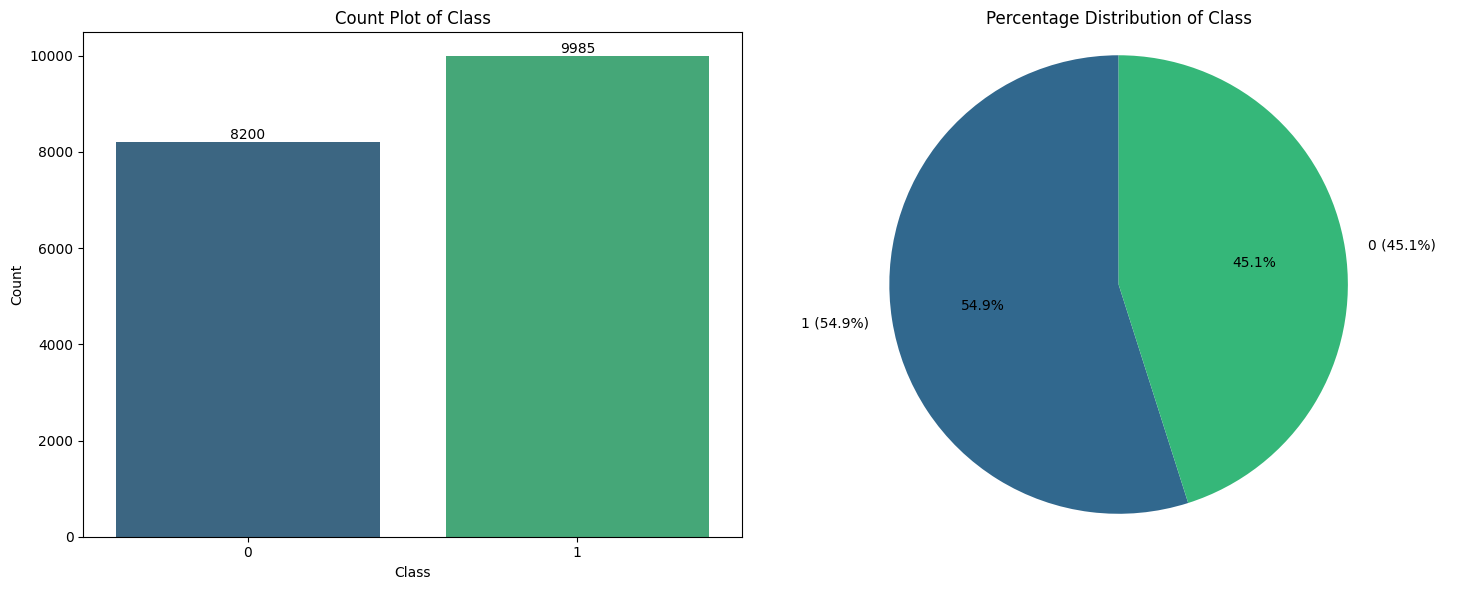

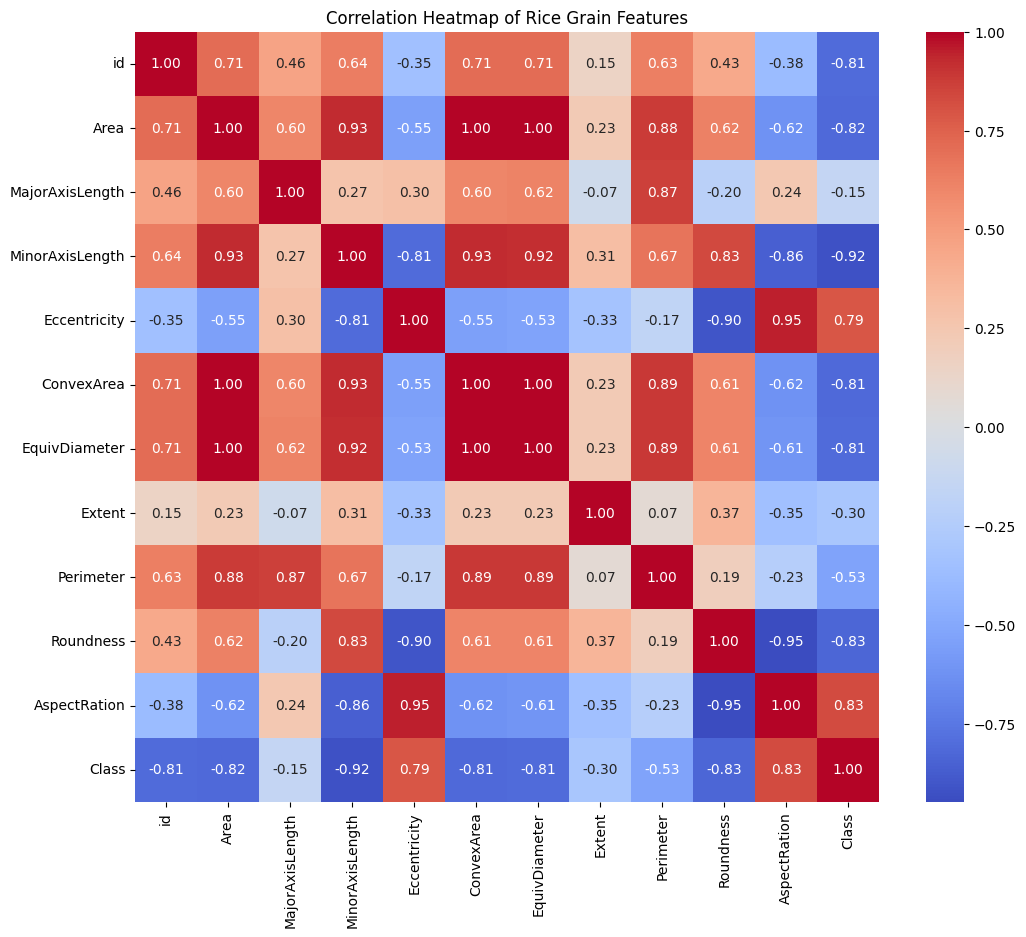

In [4]:
def plot_categorical_distribution(df, column_name):
    """
    Plots a count plot and a pie chart with percentages for a given categorical column.

    Args:
        df (pd.DataFrame): The input DataFrame.
        column_name (str): The name of the categorical column to plot.
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Count Plot
    sns.countplot(x=column_name, data=df, ax=axes[0], hue=column_name, palette='viridis', legend=False)
    axes[0].set_title(f'Count Plot of {column_name}')
    axes[0].set_xlabel(column_name)
    axes[0].set_ylabel('Count')

    # Add counts on top of bars
    for p in axes[0].patches:
        axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')

    # Pie Chart
    counts = df[column_name].value_counts()
    percentages = counts / len(df) * 100
    labels = [f'{idx} ({val:.1f}%)' for idx, val in zip(counts.index, percentages)]
    axes[1].pie(counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', len(counts)))
    axes[1].set_title(f'Percentage Distribution of {column_name}')
    axes[1].axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

    plt.tight_layout()
    plt.show()

# Apply the function to the target column
plot_categorical_distribution(df, config.target)

# Correlation Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Rice Grain Features')
plt.show()

# Dataset and Dataloader:

In [45]:
def get_scaler(cfg: config = config):
    if cfg.scaler == "standard":
        scaler = StandardScaler()
    elif cfg.scaler == "minmax":
        scaler = MinMaxScaler()
    elif cfg.scaler == "robust":
        scaler = RobustScaler()
    else:
        raise ValueError('scaler parameter should be one of "standard" , "minmax" , "robust"')
    return scaler

class RiceDataset(Dataset):
    """
    Custom PyTorch Dataset for rice type classification.
    """
    def __init__(self, df: pd.DataFrame, label: str = config.target, scaler = None):
        """
        Args:
            df (pd.DataFrame): The input DataFrame containing features and labels.
            label (str): the name of the target column.
            scaler: scaler for training, fitted scaler (for validation), or none for automatically initialize scaler based on the config class
        """
        features, target = df.drop(columns=[label]), df[label].values
        self._scaler = scaler or get_scaler()
        if scaler is None: # the scaler is not fitted
            self._fit_scaler(df=features)
        self.features = self._scaler.transform(features)
        self.target = target
        print("Dataset Initialized successfully")
    
    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        features = torch.from_numpy(self.features[index])
        target = torch.tensor(self.target[index]).float()
        return features, target

    def _fit_scaler(self, df: pd.DataFrame):
        """
        A method to fit the dataset scaler
        Args:
            df: data to be fitted
        """
        print("Fitting Scaler")
        self._scaler.fit(df)
    def get_scaler(self):
        return self._scaler


def prepare_datasets(df):
    # using 70 15 15 strategy for train, val, test datasets
    x_train, x_test_full = train_test_split(df,test_size=0.3, stratify=df[config.target])
    x_test, x_val = train_test_split(x_test_full, test_size=0.5, stratify=x_test_full[config.target])
    return x_train, x_val, x_test

train, val, test = prepare_datasets(df)

def get_loaders(df):
    train, val, test = prepare_datasets(df)
    train_ds = RiceDataset(train)
    val_ds = RiceDataset(val, scaler = train_ds.get_scaler())
    test_ds = RiceDataset(test, scaler = train_ds.get_scaler())

    train_dataloader = DataLoader(
        train_ds, **config.dataloader_configs
    )
    val_dataloader = DataLoader(
        val_ds, **config.dataloader_configs
    )
    test_dataloader = DataLoader(
        test_ds, **config.dataloader_configs
    )
    return train_dataloader, val_dataloader, test_dataloader

# Modelling :

## Model architecture:

In [ ]:
class FullyConnectedLayer(nn.Module):
    """
    Fully connected layer with ReLU activation.
    """
    def __init__(self, in_features: int, out_features: int, dropout_rate: float = 0.2):
        """
        Args:
            in_features (int): Number of input features
            out_features (int): Number of output features
            dropout_rate (float, optional): Dropout rate. Defaults to 0.2
        """
        super(FullyConnectedLayer, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(in_features, out_features),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
    def forward(self, x):
        return self.fc(x)


class RiceTypeClassifier(nn.Module):
    """
    Deep learning model for rice type classification.
    Architecture: 2 hidden layers with ReLU activation:
    - Input layer: 64 neurons
    - Hidden layer 1: 128 neurons
    - Hidden layer 2: 64 neurons
    - Output layer: 1 neurons (binary classification)
    """
    def __init__(self, input_size: int):
        """
        Args:
            input_size (int): Number of input features.
        """
        super(RiceTypeClassifier, self).__init__()

        # building the architecture:
        self.net = nn.Sequential(
            FullyConnectedLayer(input_size, 128),
            FullyConnectedLayer(128, 64),
            nn.Linear(64, 1),
        )
    def forward(self, x):
        return self.net(x)